# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
<br><br>
When evaluating the simple linear models without interactions or transformations, the combined model performed the best. The numeric-only model was very weak, achieving a Test $R^2$ of 0.130 and a Test RMSE of 66.26. The categorical-only model performed much better, with a Test $R^2$ of 0.475 and a Test RMSE of 51.45. By combining both sets of features, the model improved to a Test $R^2$ of 0.516 and a Test RMSE of 49.44. This shows that categorical features like "Room Type" and "Neighbourhood" drive the majority of the pricing signal, but combining them with numeric features like "Beds" yields the most accurate simple model.
<br><br>
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities? 
<br><br>
The partial correlation plots isolate the effect of each numeric variable on price while holding the others constant, revealing notable non-linearities. The Beds variable displays a roughly linear relationship with price initially, but the points fan out drastically at higher numbers, indicating diminishing or unpredictable returns for very large properties. The Number of Reviews shows a flat, dense cluster rather than a linear slope, suggesting review volume doesn't directly correlate with price. Finally, the Review Scores Rating is severely left-skewed, with the vast majority of scores clustered near 100, meaning its relationship to price acts more like a threshold or categorical tier rather than a continuous linear trend.
<br><br>
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
<br><br>
To build a more complex model, the numeric features were expanded using degree-2 polynomial transformations and then combined with the categorical variables. This complex model achieved a Train $R^2$ of 0.512 (RMSE: 49.15) and a Test $R^2$ of 0.517 (RMSE: 49.36). Compared to the simple combined model, this is only a very marginal improvement (the Test $R^2$ increased by just 0.001). This indicates that introducing squares and interactions for the numeric variables does not unlock any substantial hidden predictive power; the simpler model was already capturing almost all the available signal.
<br><br>
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
<br><br>
Throughout these steps, a key lesson in model selection is that adding complexity does not automatically yield better results. Because the Train $R^2$ and Test $R^2$ remained almost identical across all our models, we successfully avoided overfitting (our models generalize perfectly to unseen data without memorizing noise). However, because the absolute best model only captures about 51.7% of the variance in price, we are likely underfitting. This suggests that the current variables in the dataset simply do not contain enough information to fully explain Airbnb prices, and we are likely missing crucial features like square footage, specific amenities, or exact distance to attractions.
<br><br>
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.
<br><br>
Applying Lasso regularization to the complex model yielded a Test $R^2$ of 0.517 and a Test RMSE of 49.39. Lasso achieved this while effectively shrinking the coefficients of less useful features to exactly zero, selecting only 27 out of the available features. This means it achieved the exact same predictive performance as the bulky complex model but with a much sparser, more interpretable equation, proving that several of the polynomial expansions were just statistical noise.

--- Simple Models ---
[Numeric Variables Only] Train R^2: 0.129, RMSE: 65.65 | Test R^2: 0.130, RMSE: 66.26
[Categorical Variables Only] Train R^2: 0.468, RMSE: 51.30 | Test R^2: 0.475, RMSE: 51.45
[Combined Model] Train R^2: 0.507, RMSE: 49.40 | Test R^2: 0.516, RMSE: 49.44

Generating Partial Correlation Plots...


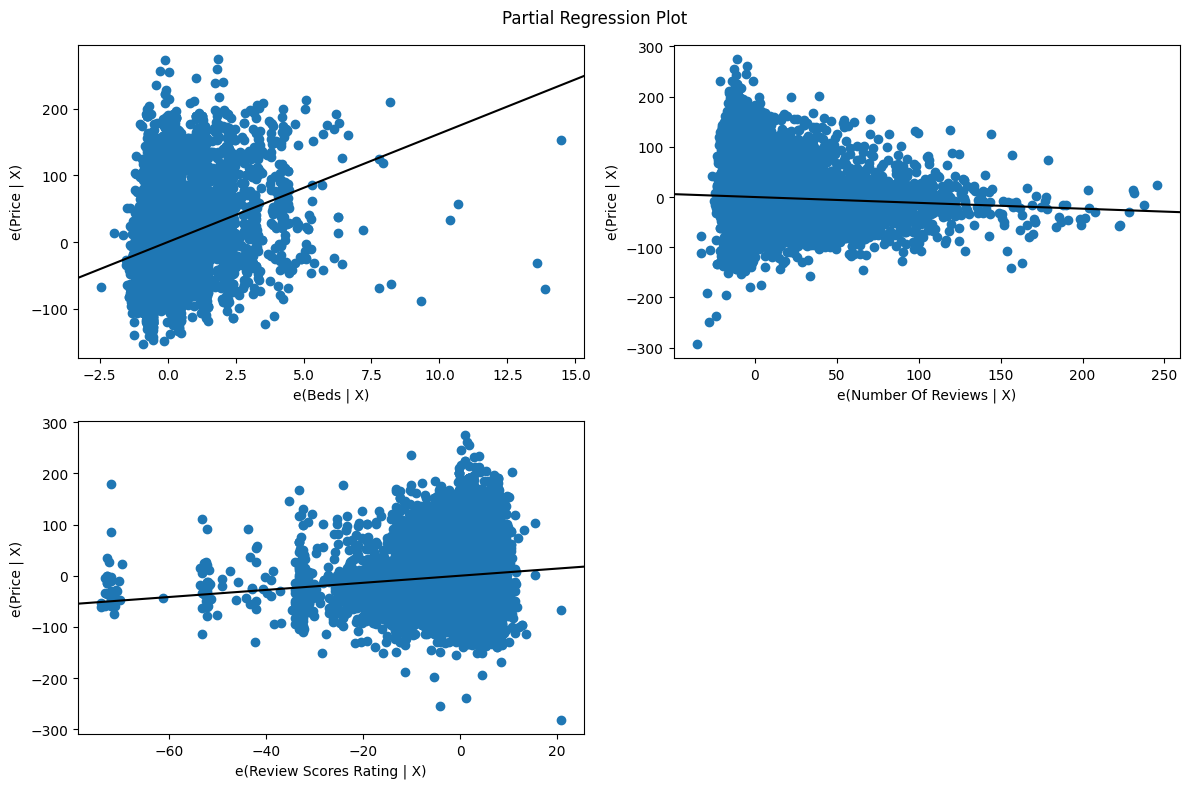


--- Complex Model ---
[Complex Model] Train R^2: 0.512, RMSE: 49.15 | Test R^2: 0.517, RMSE: 49.36

--- Lasso Regularization ---
[Lasso Model] Train R^2: 0.510, RMSE: 49.26 | Test R^2: 0.517, RMSE: 49.39
Lasso selected 27 out of 33 features.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import statsmodels.api as sm

# 1. Load and Clean the Data
file_path = "/Users/hanimoudarres/Downloads/Foundations of ML/linear_models/assignment/data/airbnb_hw.csv"
df = pd.read_csv(file_path)

# Drop irrelevant/administrative columns
cols_to_drop = ['Host Id', 'Host Since', 'Name', 'Zipcode', 'Review Scores Rating (bin)', 'Number of Records']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Fix column naming
df.rename(columns={'Neighbourhood ': 'Neighbourhood'}, inplace=True)

# Force conversion to string, replace $ and commas, then convert to numeric
df['Price'] = df['Price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df = df.dropna(subset=['Price'])

# Fill missing numeric values with median
df['Beds'] = df['Beds'].fillna(df['Beds'].median())
df['Review Scores Rating'] = df['Review Scores Rating'].fillna(df['Review Scores Rating'].median())
df = df.dropna() # Drop remaining missing rows

# Remove Price Outliers using IQR for better linear modeling
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Price'] >= Q1 - 1.5 * IQR) & (df['Price'] <= Q3 + 1.5 * IQR)]

# 2. Transform Variables
X_num = df[['Beds', 'Number Of Reviews', 'Review Scores Rating']]
X_cat = pd.get_dummies(df[['Neighbourhood', 'Property Type', 'Room Type']], drop_first=True)
y = df['Price']

X_comb = pd.concat([X_num, X_cat], axis=1)

# 3. Train-Test Split (80/20)
X_tr, X_te, y_tr, y_te = train_test_split(X_comb, y, test_size=0.2, random_state=42)

# Helper function for evaluation
def eval_model(name, X_train, X_test):
    model = LinearRegression().fit(X_train, y_tr)
    r2_train = model.score(X_train, y_tr)
    rmse_train = np.sqrt(mean_squared_error(y_tr, model.predict(X_train)))
    r2_test = model.score(X_test, y_te)
    rmse_test = np.sqrt(mean_squared_error(y_te, model.predict(X_test)))
    print(f"[{name}] Train R^2: {r2_train:.3f}, RMSE: {rmse_train:.2f} | Test R^2: {r2_test:.3f}, RMSE: {rmse_test:.2f}")
    return model

# 4. Simple Linear Models
print("--- Simple Models ---")
m_num = eval_model("Numeric Variables Only", X_tr[X_num.columns], X_te[X_num.columns])
m_cat = eval_model("Categorical Variables Only", X_tr[X_cat.columns], X_te[X_cat.columns])
m_comb = eval_model("Combined Model", X_tr, X_te)

# 5. Partial Correlation Plots
print("\nGenerating Partial Correlation Plots...")
fig = plt.figure(figsize=(12, 8))

# Convert booleans to integers for statsmodels compatibility
X_tr_sm = X_tr.copy()
for col in X_tr_sm.select_dtypes(include=['bool']).columns:
    X_tr_sm[col] = X_tr_sm[col].astype(int)

X_train_sm = sm.add_constant(X_tr_sm)
model_sm = sm.OLS(y_tr, X_train_sm).fit()

sm.graphics.plot_partregress_grid(model_sm, exog_idx=['Beds', 'Number Of Reviews', 'Review Scores Rating'], fig=fig)
plt.tight_layout()
plt.show()

# 6. Complex Model (Polynomial Expansions)
print("\n--- Complex Model ---")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_num_tr_poly = poly.fit_transform(X_tr[X_num.columns])
X_num_te_poly = poly.transform(X_te[X_num.columns])

# Combine the expanded numeric features with the categorical ones
X_tr_complex = np.hstack([X_num_tr_poly, X_tr[X_cat.columns].astype(int).values])
X_te_complex = np.hstack([X_num_te_poly, X_te[X_cat.columns].astype(int).values])

m_comp = LinearRegression().fit(X_tr_complex, y_tr)
r2_tr_c = m_comp.score(X_tr_complex, y_tr)
rmse_tr_c = np.sqrt(mean_squared_error(y_tr, m_comp.predict(X_tr_complex)))
r2_te_c = m_comp.score(X_te_complex, y_te)
rmse_te_c = np.sqrt(mean_squared_error(y_te, m_comp.predict(X_te_complex)))
print(f"[Complex Model] Train R^2: {r2_tr_c:.3f}, RMSE: {rmse_tr_c:.2f} | Test R^2: {r2_te_c:.3f}, RMSE: {rmse_te_c:.2f}")

# 8. Lasso Regularization
print("\n--- Lasso Regularization ---")
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_complex)
X_te_scaled = scaler.transform(X_te_complex)

# Fit Lasso
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_tr_scaled, y_tr)
r2_tr_l = lasso.score(X_tr_scaled, y_tr)
rmse_tr_l = np.sqrt(mean_squared_error(y_tr, lasso.predict(X_tr_scaled)))
r2_te_l = lasso.score(X_te_scaled, y_te)
rmse_te_l = np.sqrt(mean_squared_error(y_te, lasso.predict(X_te_scaled)))

print(f"[Lasso Model] Train R^2: {r2_tr_l:.3f}, RMSE: {rmse_tr_l:.2f} | Test R^2: {r2_te_l:.3f}, RMSE: {rmse_te_l:.2f}")

# Feature Selection Insight
feature_names = list(poly.get_feature_names_out(X_num.columns)) + list(X_cat.columns)
selected = [feature_names[i] for i, coef in enumerate(lasso.coef_) if abs(coef) > 1e-4]
print(f"Lasso selected {len(selected)} out of {len(feature_names)} features.")